## 0. Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
# general
from pathlib import Path

import geopandas as gpd

# for plotting and coloring
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

gpd.options.io_engine = "pyogrio"

In [3]:
from gridsample.utils import create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [4]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [5]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "Panel" / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "Panel" / "03. Final Outputs" / "v1"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load MapSolve boundaries

In [6]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [7]:
gdf = gdf.drop_duplicates()

In [8]:
# fix issues
gdf.loc[gdf["TV_C"] == 803014, "SubDist_N"] = "Tirupati (Urban)"
gdf.loc[gdf["TV_C"] == 803014, "SubDist_C"] = 5383
gdf.loc[(gdf["TV_C"] == 801373) & (gdf["Ward_C"] == "3"), "PCA_ID"] = "801373-3"

<Axes: >

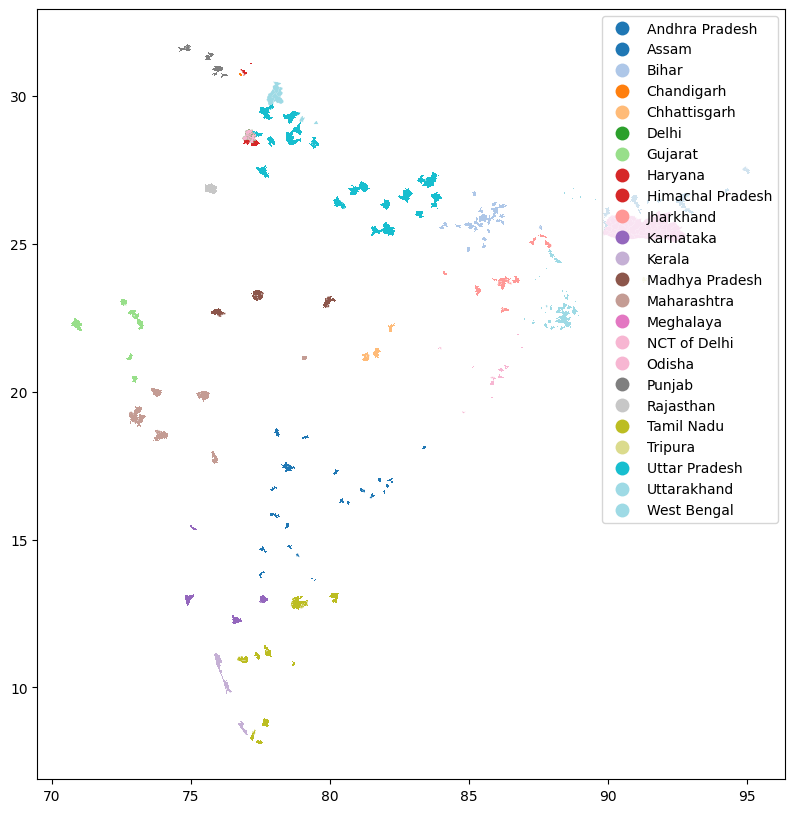

In [9]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

## 2. Load sampled wards data

In [10]:
# load the merged wards data
sample_df = pd.read_csv(
    CLEANED_DATA_DIR
    / "00. Merge and Quality Checks"
    / "v1"
    / "Panel Wards with Quality Checks.csv"
)

In [11]:
sample_df

,State,State_Name,District,District_Name,Subdistrict,Subd_Name,TownVillage,UrbanWardVillage,WardVillage_Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,16,Shimla (M Corp.) WARD NO.-0016,800137-16,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-16,1
1,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,22,Shimla (M Corp.) WARD NO.-0022,800137-22,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-22,1
2,2,HIMACHAL PRADESH,33,Shimla,182,Shimla (urban),800137,23,Shimla (M Corp.) WARD NO.-0023,800137-23,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-23,1
3,3,PUNJAB,37,Jalandhar,212,Jalandhar - I,800165,7,Jalandhar Cantt. (CB) WARD NO.-0007,800165-7,...,No,True,No,True,True,False,GOOD - Ward boundary given as expected,ward,WARD_800165-7,1
4,3,PUNJAB,37,Jalandhar,212,Jalandhar - I,800166,1,Jalandhar (M Corp.) WARD NO.-0001,800166-1,...,No,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_800166-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,90,TELANGANA,537,Rangareddy,4523,Ghatkesar,574163,0,Korremul,574163-0,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_574163,1
708,90,TELANGANA,537,Rangareddy,4523,Ghatkesar,574173,1,Peerzadguda (CT) WARD NO.-0001,574173-1,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_574173,1
709,90,TELANGANA,538,Mahbubnagar,4568,Mahbubnagar,802922,4,Mahbubnagar (M) WARD NO.-0004,802922-4,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_802922,1
710,90,TELANGANA,541,Khammam,4757,Khammam (Urban),579685,1,Khanapuram Haveli (CT) WARD NO.-0001,579685-1,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_579685,1


### 2.1 Rename and clean both datasets

In [12]:
rename_dict = {
    "UID": "UID",
    "PCA_ID": "PCA_ID",
    "State_C": "State Code",
    "State_N": "State Name",
    "Dist_C": "District Code",
    "Dist_N": "District Name",
    "SubDist_C": "Subdistrict Code",
    "SubDist_N": "Subdistrict Name",
    "TV_C": "TV Code",
    "TV_N": "TV Name",
    "Ward_C": "Ward Code",
    "TOT_P": "Total Population",
}

gdf = gdf.rename(columns=rename_dict)

In [13]:
rename_dict = {
    "State": "State Code",
    "State_Name": "State Name",
    "District": "District Code",
    "District_Name": "District Name",
    "Subdistrict": "Subdistrict Code",
    "Subd_Name": "Subdistrict Name",
    "TownVillage": "TV Code",
    "UrbanWardVillage": "Ward Code",
    "WardVillage_Name": "Ward/Village Name",
    "TRU": "Urban/Rural",
    "WardVillage_Pop": "Ward Population",
    "Subd_Pop": "Subdistrict Population",
    "State_Pop": "State Population",
    "WardVillageID": "Complete ID",
}
sample_df = sample_df.rename(columns=rename_dict)

# make State Name heading case instead of all caps
sample_df["State Name"] = sample_df["State Name"].str.title()
sample_df.loc[sample_df["State Name"] == "Nct Of Delhi", "State Name"] = "NCT of Delhi"

In [14]:
# make relevant codes into floats for both datasets
code_columns = [
    "State Code",
    "District Code",
    "Subdistrict Code",
    "TV Code",
    "Ward Code",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(float)
    gdf[col] = gdf[col].astype(float)

In [15]:
sample_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,16.0,Shimla (M Corp.) WARD NO.-0016,800137-16,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-16,1
1,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,22.0,Shimla (M Corp.) WARD NO.-0022,800137-22,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-22,1
2,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,23.0,Shimla (M Corp.) WARD NO.-0023,800137-23,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-23,1
3,3.0,Punjab,37.0,Jalandhar,212.0,Jalandhar - I,800165.0,7.0,Jalandhar Cantt. (CB) WARD NO.-0007,800165-7,...,No,True,No,True,True,False,GOOD - Ward boundary given as expected,ward,WARD_800165-7,1
4,3.0,Punjab,37.0,Jalandhar,212.0,Jalandhar - I,800166.0,1.0,Jalandhar (M Corp.) WARD NO.-0001,800166-1,...,No,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_800166-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,90.0,Telangana,537.0,Rangareddy,4523.0,Ghatkesar,574163.0,0.0,Korremul,574163-0,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_574163,1
708,90.0,Telangana,537.0,Rangareddy,4523.0,Ghatkesar,574173.0,1.0,Peerzadguda (CT) WARD NO.-0001,574173-1,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_574173,1
709,90.0,Telangana,538.0,Mahbubnagar,4568.0,Mahbubnagar,802922.0,4.0,Mahbubnagar (M) WARD NO.-0004,802922-4,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_802922,1
710,90.0,Telangana,541.0,Khammam,4757.0,Khammam (Urban),579685.0,1.0,Khanapuram Haveli (CT) WARD NO.-0001,579685-1,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_579685,1


## 3. Filter MapSolve boundaries to sampled areas

### 3.2 Drop unnecessary rows 

#### Drop rows with no MapSolve shapes

In [16]:
sample_df[sample_df["PSU Type"] == "none"]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
497,24.0,Gujarat,486.0,Vadodara,3898.0,Vadodara,802596.0,18.0,Gorva (OG) WARD NO.-0018 (Rural MDDS CODE:519923),802596-18,...,No,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3898,0
705,90.0,Telangana,537.0,Rangareddy,4518.0,Qutubullapur,802918.0,157.0,Mallampet (OG) WARD NO.-0157 (Rural MDDS CODE:...,802918-157,...,Yes,True,Previously Andhra Pradesh,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_4518,0


In [17]:
filtered_df = sample_df[sample_df["PSU Type"] != "none"]

In [18]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,16.0,Shimla (M Corp.) WARD NO.-0016,800137-16,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-16,1
1,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,22.0,Shimla (M Corp.) WARD NO.-0022,800137-22,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-22,1
2,2.0,Himachal Pradesh,33.0,Shimla,182.0,Shimla (urban),800137.0,23.0,Shimla (M Corp.) WARD NO.-0023,800137-23,...,No,True,No,True,False,False,BETTER - Ward boundary given but only TV or Su...,ward,WARD_800137-23,1
3,3.0,Punjab,37.0,Jalandhar,212.0,Jalandhar - I,800165.0,7.0,Jalandhar Cantt. (CB) WARD NO.-0007,800165-7,...,No,True,No,True,True,False,GOOD - Ward boundary given as expected,ward,WARD_800165-7,1
4,3.0,Punjab,37.0,Jalandhar,212.0,Jalandhar - I,800166.0,1.0,Jalandhar (M Corp.) WARD NO.-0001,800166-1,...,No,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_800166-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,90.0,Telangana,537.0,Rangareddy,4523.0,Ghatkesar,574163.0,0.0,Korremul,574163-0,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_574163,1
708,90.0,Telangana,537.0,Rangareddy,4523.0,Ghatkesar,574173.0,1.0,Peerzadguda (CT) WARD NO.-0001,574173-1,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_574173,1
709,90.0,Telangana,538.0,Mahbubnagar,4568.0,Mahbubnagar,802922.0,4.0,Mahbubnagar (M) WARD NO.-0004,802922-4,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_802922,1
710,90.0,Telangana,541.0,Khammam,4757.0,Khammam (Urban),579685.0,1.0,Khanapuram Haveli (CT) WARD NO.-0001,579685-1,...,Yes,True,Previously Andhra Pradesh,False,True,False,GOOD - Town/Village boundary given as expected,town_village,TV_579685,1


In [19]:
# check bad rows, leave as is though
filtered_df[filtered_df["Delivery State"].str.contains("BAD")]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


#### Drop duplicate rows if PSU is TV or Subdistrict

In [20]:
filtered_df = filtered_df[
    # if the PSU Type is "town_village", then drop any duplicated rows with the same TV Code
    ~(
        (filtered_df["PSU Type"] == "town_village")
        & (filtered_df.duplicated(subset=["TV Code"], keep="first"))
    )
    # similar for subdistrict
    & ~(
        (filtered_df["PSU Type"] == "subdistrict")
        & (filtered_df.duplicated(subset=["Subdistrict Code"], keep="first"))
    )
]

filtered_df.value_counts("PSU Type")

PSU Type
ward            322
town_village    277
subdistrict      17
Name: count, dtype: int64

#### Duplicated wards

In [21]:
filtered_df[filtered_df["PCA_ID"].duplicated(keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
103,7.0,NCT of Delhi,90.0,North West,431.0,Saraswati Vihar,800441.0,59.0,DMC (U) (Part) WARD NO.-0059,800441-59,...,No,True,No,True,False,True,GOOD - Ward boundary given as expected,ward,WARD_800441-59,1
142,7.0,NCT of Delhi,96.0,West,448.0,Patel Nagar,800441.0,99.0,DMC (U) (Part) WARD NO.-0099,800441-99,...,No,True,No,True,False,True,GOOD - Ward boundary given as expected,ward,WARD_800441-99,1
154,7.0,NCT of Delhi,96.0,West,450.0,Punjabi Bagh,800441.0,59.0,DMC (U) (Part) WARD NO.-0059,800441-59,...,No,True,No,True,False,True,GOOD - Ward boundary given as expected,ward,WARD_800441-59,1
155,7.0,NCT of Delhi,96.0,West,450.0,Punjabi Bagh,800441.0,99.0,DMC (U) (Part) WARD NO.-0099,800441-99,...,No,True,No,True,False,True,GOOD - Ward boundary given as expected,ward,WARD_800441-99,1


In [22]:
print(f"Number of rows before dropping PCA_ID duplicates: {len(filtered_df)}")
print(
    f"Number of rows after dropping PCA_ID duplicates: {len(filtered_df.drop_duplicates(subset=['PCA_ID'], keep='first'))}"
)

Number of rows before dropping PCA_ID duplicates: 616
Number of rows after dropping PCA_ID duplicates: 614


In [23]:
filtered_df = filtered_df.drop_duplicates(subset=["PCA_ID"], keep="first")

#### Check for duplicated `PSU ID`

In [27]:
filtered_df[filtered_df.duplicated(subset=["PSU ID"], keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Included in Panel,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


In [28]:
filtered_df = filtered_df.drop_duplicates(subset=["PSU ID"], keep="first")
len(filtered_df) == filtered_df["PSU ID"].nunique()

True

## 4. Merge shapes at the respective PSU level

### Wards

In [44]:
# PCA IDs to match (TVCode-WardCode)
pca_ids_to_match = filtered_df.loc[filtered_df["PSU Type"] == "ward", "PCA_ID"].unique()
len(pca_ids_to_match)

320

In [45]:
wards_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "ward"].merge(
        gdf[gdf["PCA_ID"].isin(pca_ids_to_match)],
        on=["PCA_ID"],
        how="left",
        suffixes=("", "_MapSolve"),
    ),
    geometry="geometry",
)
wards_gdf.shape

(321, 38)

### Town/Village

In [46]:
# TV codes to match
tv_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "town_village", "TV Code"
].unique()
len(tv_codes_to_match)

277

In [47]:
tv_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "town_village"].merge(
        gdf[gdf["TV Code"].isin(tv_codes_to_match) & gdf["Ward Code"].isna()],
        on=["TV Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
tv_gdf.shape

(278, 38)

In [48]:
# cut out the ward geometries from the TV geometries so we don't double sample those areas
trimmed_tv_geoms = tv_gdf.difference(wards_gdf.geometry.unary_union)
trimmed_tv_gdf = gpd.GeoDataFrame(
    tv_gdf.drop(columns="geometry").assign(geometry=trimmed_tv_geoms),
    crs=tv_gdf.crs,
)

### Subdistrict

In [49]:
# subdistrict codes to match
subdistrict_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "subdistrict", "Subdistrict Code"
].unique()
len(subdistrict_codes_to_match)

17

In [51]:
subdistrict_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "subdistrict"].merge(
        gdf[
            gdf["Subdistrict Code"].isin(subdistrict_codes_to_match)
            & (gdf["TV Code"].isna())
            & (gdf["Ward Code"].isna())
        ],
        on=["Subdistrict Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)

In [52]:
# cut out the TV and Ward geometries from the subdistrict geometries so we don't double sample those areas
combined_tv_and_ward_union_shape = wards_gdf.geometry.unary_union.union(
    trimmed_tv_gdf.geometry.unary_union
)
trimmed_subdistrict_geoms = subdistrict_gdf.difference(combined_tv_and_ward_union_shape)
trimmed_subdistrict_gdf = gpd.GeoDataFrame(
    subdistrict_gdf.drop(columns="geometry").assign(geometry=trimmed_subdistrict_geoms),
    crs=subdistrict_gdf.crs,
)

### Combine

In [53]:
# combine all three GeoDataFrames into one
combined_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            wards_gdf,
            trimmed_tv_gdf,
            trimmed_subdistrict_gdf,
        ],
        ignore_index=True,
    )
)
combined_gdf = combined_gdf.sort_values(
    by=["State Code", "District Code", "Subdistrict Code", "TV Code", "Ward Code"]
).reset_index(drop=True)

<Axes: >

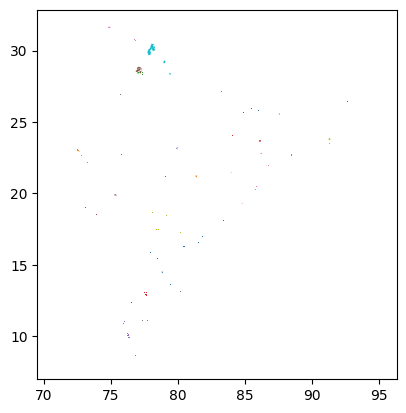

In [54]:
combined_gdf.plot(column="State Name")

### Drop rows duplicated `PSU ID` (could happen)

In [66]:
duplicated_psu_id_gdf = combined_gdf[combined_gdf.duplicated(subset=["PSU ID"], keep=False)]
duplicated_psu_id_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve
342,21.0,Odisha,377.0,Baleshwar,2909.0,Baleshwar (M),801833.0,4.0,Baleshwar (M) WARD NO.-0004,801833-4,...,377.0,Baleshwar,2909.0,Baleshwar (M),801833.0,Baleshwar (M),4.0,3612.0,"MULTIPOLYGON (((86.94946 21.48747, 86.95027 21...",NaN
343,21.0,Odisha,377.0,Baleshwar,2909.0,Baleshwar (M),801833.0,4.0,Baleshwar (M) WARD NO.-0004,801833-4,...,377.0,Baleshwar,2909.0,Baleshwar (M),801833.0,Baleshwar (M),4.0,3612.0,"MULTIPOLYGON (((86.94866 21.48772, 86.94946 21...",NaN
542,32.0,Kerala,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,628518.0,1.0,Venganoor (CT) WARD NO.-0001,628518-1,...,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,NaN,Venganoor (CT),NaN,35963.0,"POLYGON ((77.00296 8.42060, 77.00350 8.42060, ...",628518
543,32.0,Kerala,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,628518.0,1.0,Venganoor (CT) WARD NO.-0001,628518-1,...,601.0,Thiruvananthapuram,5691.0,Thiruvananthapuram,NaN,Venganoor (CT),NaN,35963.0,"POLYGON ((77.00296 8.42087, 77.00296 8.42060, ...",628518


PSU ID
TV_628518         Axes(0.125,0.22375;0.775x0.5425)
WARD_801833-4    Axes(0.247812,0.11;0.529375x0.77)
dtype: object

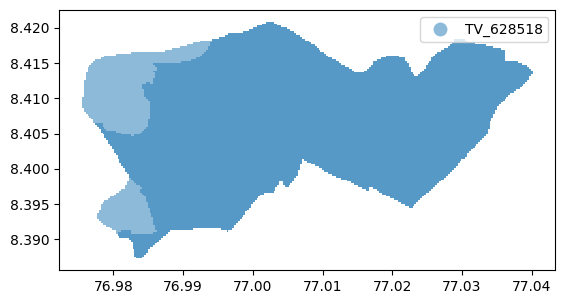

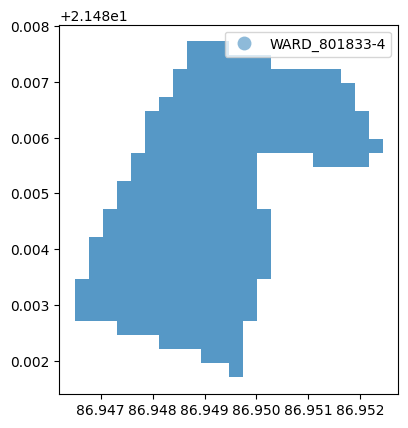

In [71]:
duplicated_psu_id_gdf.groupby("PSU ID").plot(alpha=0.5, column="PSU ID", legend=True)

In [72]:
combined_gdf = combined_gdf.drop_duplicates(subset=["PSU ID"], keep="first")
len(combined_gdf) == combined_gdf["PSU ID"].nunique()

True

In [73]:
combined_gdf["UID"] = combined_gdf["UID"].astype(str)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [74]:
len(combined_gdf) == combined_gdf["PSU ID"].nunique()

True

In [75]:
save_shapefiles(
    combined_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "all_sampled_PSUs",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Shimla (M Corp.) WARD NO.-0016' of field all_sampled_PSUs.TV Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '800137-16' of field all_sampled_PSUs.Ward Code parsed incompletely to real 800137.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'BETTER - Ward boundary given but only TV or Subdistrict was expected' for boolean field all_sampled_PSUs.TV Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'ward' for boolean field all_sampled_PSUs.SubDistrict Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/l

## 5. Download rooftops

#### Identify S2 cell IDs

In [76]:
s2_cell_ids = get_s2_cell_ids(combined_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 4
Shapes with spillover after round 2: 0


/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:126: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:139: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")


85

#### Check if identified cells cover all areas of interest

In [77]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [78]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = combined_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


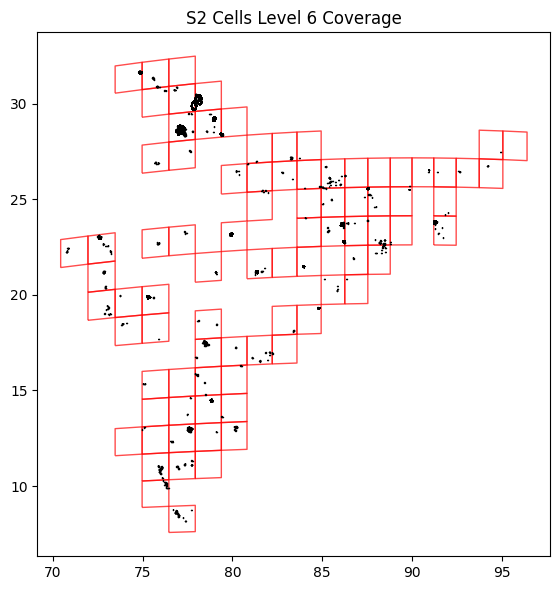

In [79]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
combined_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [80]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        combined_gdf[["State Name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [81]:
# note: this will have duplicate s2 cell rows with different state names if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,State Name
0,4108690235045445632,"POLYGON ((76.45631 30.91143, 77.92817 31.05912...",Himachal Pradesh
1,4114882684533080064,"POLYGON ((74.96764 30.74458, 76.45631 30.91143...",Punjab
3,4114319734579658752,"POLYGON ((73.46516 30.55831, 74.96764 30.74458...",Punjab
2,4112067934765973504,"POLYGON ((74.96764 29.29986, 76.45631 29.46195...",Punjab
4,4111504984812552192,"POLYGON ((76.45631 29.46195, 77.92817 29.60547...",Punjab
...,...,...,...
76,4298967319301849088,"POLYGON ((76.45631 10.33079, 77.92817 10.38998...",Tamil Nadu
77,4299530269255270400,"POLYGON ((77.92817 10.38998, 79.38034 10.44180...",Tamil Nadu
78,4309100418463432704,"POLYGON ((77.92817 17.67399, 79.38034 17.75846...",Telangana
79,4308537468510011392,"POLYGON ((77.92817 16.18854, 79.38034 16.26673...",Telangana


#### Download the S2 cells

In [82]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4108690235045445632 already exists.
File 4114882684533080064 already exists.
File 4112067934765973504 already exists.
File 4114319734579658752 already exists.
File 4111504984812552192 already exists.
File 4109816134952288256 already exists.
File 4110379084905709568 already exists.
File 4110942034859130880 already exists.
File 4137963632623353856 already exists.
File 4139652482483617792 already exists.
File 4152600331412307968 already exists.
File 4150911481552044032 already exists.
File 4150348531598622720 already exists.
File 4151474431505465344 already exists.
File 4144719032064409600 already exists.
File 4148096731784937472 already exists.
File 4149222631691780096 already exists.
File 4149785581645201408 already exists.
File 4148659681738358784 already exists.
File 4173992429642317824 already exists.
File 4174555379595739136 already exists.
File 4177933079316267008 already exists.
File 4175681279502581760 already exists.
File 4146970831878094848 already exists.
File 39865300951

## 6. Load rooftops and match to areas

In [ ]:
state_names = combined_gdf["State Name"].sort_values().unique()

for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State Name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = combined_gdf[combined_gdf["State Name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_file_dir=RAW_DATA_DIR / "02. Rooftop Data",
            s2_cell_id=s2_cell_id,
            boundaries_gdf=gdf_subset,
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State Name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/22 [00:00<?, ?it/s]

Processing state: Andhra Pradesh
Number of S2 cells that overlap our shapes in Andhra Pradesh: 10


  0%|          | 0/10 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results fro

Processing state: Assam
Number of S2 cells that overlap our shapes in Assam: 8


  0%|          | 0/8 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results fro

Processing state: Bihar
Number of S2 cells that overlap our shapes in Bihar: 7


  0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
ax = matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)
gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [ ]:
matched_rooftop_dir = CLEANED_DATA_DIR / "01. Matched Rooftop Data"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# # filter to those that have selected_states in the name
# all_filepaths = [
#     f for f in all_filepaths if any(state in f.parent.name for state in selected_states)
# ]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

In [ ]:
len(matched_rooftops_gdf)

In [ ]:
no_rooftop_PSU_IDs = set(combined_gdf["PSU ID"].unique()).difference(
    set(matched_rooftops_gdf["PSU ID"].unique())
)
no_rooftop_PSU_gdf = combined_gdf[combined_gdf["PSU ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

In [ ]:
no_rooftop_PSU_gdf.to_csv(
    OUTPUT_DATA_DIR / "Sampled PSUs" / "PSU_IDs_with_no_rooftops.csv",
    index=False,
)

## 8. Sample rooftops

In [ ]:
# Define the base number of rooftops per ward
ROOFTOPS_PER_WARD = 75

# Sample rooftops, multiplying by Ward Count for each PSU.
sampled_rooftops = matched_rooftops_gdf.groupby("PSU ID", group_keys=False).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_WARD * int(x["Ward Count"].iloc[0]), x.shape[0]),
        random_state=42,
    )
)

In [ ]:
len(matched_rooftops_gdf)

In [ ]:
len(sampled_rooftops)

In [ ]:
# Check if Ward Count is correctly influencing sample sizes
TEMP_ward_count_df = matched_rooftops_gdf[["PSU ID", "Ward Count"]].drop_duplicates()
TEMP_ward_count_df["Expected Rooftop Count"] = TEMP_ward_count_df["Ward Count"] * ROOFTOPS_PER_WARD
TEMP_sampled_counts = (
    sampled_rooftops.groupby("PSU ID").size()
).reset_index(name="Sampled Rooftop Count")

# Merge the two dataframes
TEMP_check_df = TEMP_ward_count_df.merge(TEMP_sampled_counts, on="PSU ID")
TEMP_check_df["Rooftop Count Difference"] = (
    TEMP_check_df["Expected Rooftop Count"] - TEMP_check_df["Sampled Rooftop Count"]
)
TEMP_check_df[TEMP_check_df["Rooftop Count Difference"] != 0]

In [ ]:
sampled_rooftops.plot(
    figsize=(8, 8),
    column="State Name",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [ ]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

# Rooftop number within each PSU ID
sampled_rooftops["Rooftop PSU ID"] = sampled_rooftops.groupby("PSU ID").cumcount() + 1
# add prefix of "PIN "  to the Rooftop PSU ID
sampled_rooftops["Rooftop PSU ID"] = "PIN " + sampled_rooftops["Rooftop PSU ID"].astype(
    str
)

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['PSU ID']}_ROOFTOP_{row['Rooftop PSU ID']}",
    axis=1,
)

### Add gmap link

In [ ]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop PSU ID, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [ ]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop PSU ID",
    "Rooftop Unique ID",
    ## Geospatial data
    "geometry",
    "latitude",
    "longitude",
    "gmap_link",
    ## PSU info
    "PSU ID",
    "PSU Type",
    "Ward Count",
    ## Location info
    "State Code",
    "State Name",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",
    ## Admin information
    "Included in Panel",
    "Ward Boundary Available with MapSolve",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",
    ## MapSolve location info
    "State Code_MapSolve",
    "State Name_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    "PCA_ID_MapSolve",
    "Total Population",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [ ]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [ ]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "PSU ID": "PSU ID",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

In [ ]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [ ]:
sampled_rooftops_organised_gdf

### Save sampled data (original rooftop pins)

In [ ]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet", "kml"],
)

## 9. Snap points to road

In [ ]:
import yaml
from shapely import Point

from utils import get_nearest_point_on_road, snap_points_to_roads_parallel

In [ ]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [ ]:
get_nearest_point_on_road(Point(77.11432151622034, 28.677391409999522), api_key)

In [ ]:
# test
get_nearest_point_on_road(sampled_rooftops_organised_gdf.geometry.iloc[0], api_key)

In [ ]:
len(sampled_rooftops_organised_gdf)

#### Snap points to road

In [ ]:
snapped_points_series = snap_points_to_roads_parallel(
    sampled_rooftops_organised_gdf, api_key, max_workers=12
)
# took 1min for 3,200 points

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = list(snapped_points_series)

In [ ]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

In [ ]:
sampled_rooftops_snapped_gdf

#### Replace geometry to snapped one (missing filled in with original)

In [ ]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [ ]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

#### Update lat, lon, gmap_link

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.rename(
    columns={
        "latitude": "latitude_original",
        "longitude": "longitude_original",
        "gmap_link": "gmap_link_original",
    },
)

In [ ]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Rooftop State ID",
        "Rooftop PSU ID",
        "Rooftop Unique ID",
        # new columns start
        "Geometry Type",
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # new columns end
        "geometry_original",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "PSU ID",
        "PSU Type",
        "Ward Count",
        "State Code",
        "State Name",
        "State Changed",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name_MapSolve",
        "Ward Code",
        "Ward/Village Name",
        "Urban/Rural",
        "PCA_ID",
        "Ward Population",
        "Subdistrict Population",
        "State Population",
        "Included in Panel",
        "Ward Boundary Available with MapSolve",
        "Ward Boundary Given",
        "TV Boundary Given",
        "SubDistrict Boundary Given",
        "Delivery State",
        "State Code_MapSolve",
        "State Name_MapSolve",
        "District Code_MapSolve",
        "District Name_MapSolve",
        "Subdistrict Code_MapSolve",
        "Subdistrict Name_MapSolve",
        "TV Code_MapSolve",
        "Ward Code_MapSolve",
        "PCA_ID_MapSolve",
        "PSU Total Population_MapSolve",
    ]
]

#### Make lines between original and snapped points

In [ ]:
from shapely.geometry import LineString

In [ ]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [ ]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

#### Save new files: snapped points, snapped lines

In [ ]:
# Save snapped points
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet", "kml"],
)

In [ ]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
save_shapefiles(
    sampled_rooftops_line_gdf.drop(columns=["geometry_line", "geometry_original"]),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["csv", "parquet", "kml"],
)

## Save per state

In [ ]:
for state in sampled_rooftops_organised_gdf["State Name"].unique():
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state
    save_shapefiles(
        sampled_rooftops_organised_gdf[
            sampled_rooftops_organised_gdf["State Name"] == state
        ],
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet", "kml"],
    )

    # Save snapped points
    save_shapefiles(
        sampled_rooftops_snapped_gdf[
            sampled_rooftops_snapped_gdf["State Name"] == state
        ].drop(
            columns=[
                "geometry_original",
                "geometry_line",
            ]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet", "kml"],
    )

    # Save lines
    sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
    sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
    save_shapefiles(
        sampled_rooftops_line_gdf[
            sampled_rooftops_line_gdf["State Name"] == state
        ].drop(columns=["geometry_line", "geometry_original"]),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["csv", "parquet", "kml"],
    )